# Downloading Training data from Kaggle

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dschettler8845/brats-2021-task1")

print("Path to dataset files:", path)

100%|██████████| 12.3G/12.3G [01:00<00:00, 217MB/s] 

Extracting files...


Path to dataset files: /home/atchu2504/.cache/kagglehub/datasets/dschettler8845/brats-2021-task1/versions/1


In [4]:
#extracting data from zip file
import tarfile
import os

tar_file_path = '/home/atchu2504/.cache/kagglehub/datasets/dschettler8845/brats-2021-task1/versions/1/BraTS2021_Training_Data.tar'  # Replace with your file path
extract_dir = '/home/atchu2504/training/data'  # Output directory

os.makedirs(extract_dir, exist_ok=True)

with tarfile.open(tar_file_path, 'r') as tar:
    tar.extractall(path=extract_dir)
    print("Extraction completed.")

# Verify dataset size after extraction
extracted_folders = [f for f in os.listdir(extract_dir) if os.path.isdir(os.path.join(extract_dir, f))]
print(f"Total BraTS 2021 subjects extracted: {len(extracted_folders)}")

Extraction completed.
Total BraTS 2021 subjects extracted: 1251


In [ ]:
import os
import zipfile

zip_file_path = '/home/atchu2504/.synapseCache/768/124662768/ASNR-MICCAI-BraTS2023-GLI-Challenge-ValidationData.zip'
extract_dir = '/home/atchu2504/training/validation'

os.makedirs(extract_dir, exist_ok=True)

# Use zipfile instead of tarfile
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
    print("Extraction completed.")

# Verify extraction
extracted_folders = [f for f in os.listdir(extract_dir) if os.path.isdir(os.path.join(extract_dir, f))]
print(f"Total subjects extracted: {len(extracted_folders)}")

Extraction completed.
Total subjects extracted: 1


: 

Loading dataset...
Found 1251 valid samples in /home/atchu2504/training/data

Dataset Split Summary:
Total samples: 1251
Training samples: 1000 (79.9%)
Validation samples: 251 (20.1%)

Using device: cuda

Testing train_loader...


/opt/conda/lib/python3.10/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


Train Batch - Image shape: torch.Size([4, 3, 256, 256])
Train Batch - Label shape: torch.Size([4, 3, 256, 256])


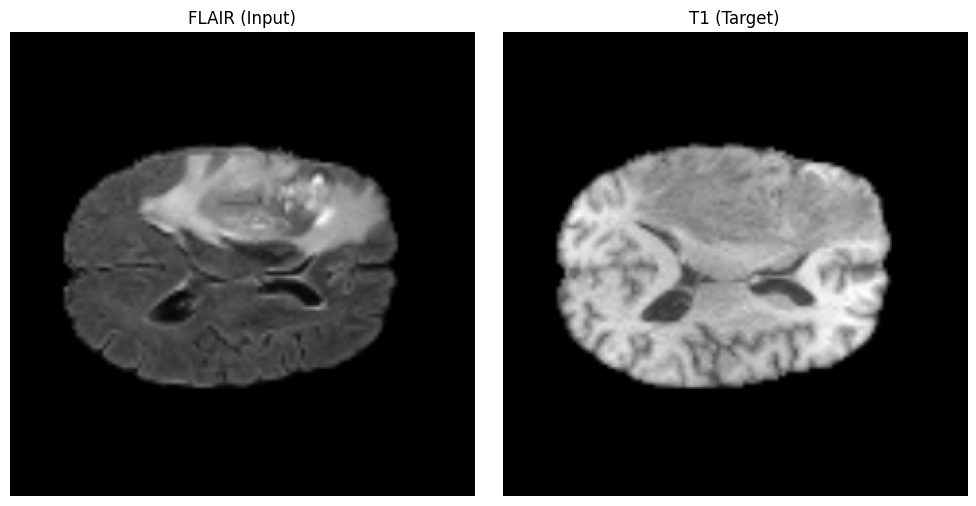


Testing val_loader...
Val Batch - Image shape: torch.Size([4, 3, 256, 256])
Val Batch - Label shape: torch.Size([4, 3, 256, 256])

✅ Data loaders created successfully!
✅ train_loader: 250 batches
✅ val_loader: 63 batches


In [2]:
# Improved Data Loading with Train/Validation Split
import os
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Orientationd, Spacingd,
    Resized, ToTensord, MapTransform, RepeatChanneld
)
from monai.utils import set_determinism
import matplotlib.pyplot as plt

# --- Custom Transforms ---

class ExtractMidSlice(MapTransform):
    """
    Custom MONAI transform to extract the middle slice of a 3D volume
    to make it 2D for processing with standard 2D models.
    """
    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            img = d[key]
            # Assuming channel first: [C, H, W, D]
            mid_idx = img.shape[-1] // 2
            d[key] = img[..., mid_idx] 
        return d

class NormalizeToOneRange(MapTransform):
    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            # Prevent division by zero
            denom = d[key].max() - d[key].min()
            if denom > 0:
                d[key] = (d[key] - d[key].min()) / denom
            else:
                d[key] = d[key] - d[key].min()
        return d

# --- Dataset Definition ---

class BraTSDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = self.get_valid_samples()

    def get_valid_samples(self):
        valid_samples = []
        if not os.path.exists(self.root_dir):
            print(f"Warning: Directory {self.root_dir} does not exist!")
            return []
        
        for folder in sorted(os.listdir(self.root_dir)):
            folder_path = os.path.join(self.root_dir, folder)
            if not os.path.isdir(folder_path): 
                continue
            
            flair_path = os.path.join(folder_path, f"{folder}_flair.nii.gz")
            t1_path = os.path.join(folder_path, f"{folder}_t1.nii.gz")
            
            if os.path.exists(flair_path) and os.path.exists(t1_path):
                valid_samples.append({"image": flair_path, "label": t1_path})
        
        print(f"Found {len(valid_samples)} valid samples in {self.root_dir}")
        return valid_samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        if self.transform:
            sample = self.transform(sample)
        return sample

# --- Pipeline Setup ---

def get_transforms():
    return Compose([
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]),
        Orientationd(keys=["image", "label"], axcodes="RAS"),
        Spacingd(keys=["image", "label"], pixdim=(2.0, 2.0, 2.0), mode=("bilinear", "nearest")),
        # Extract 2D slice early to reduce memory overhead
        ExtractMidSlice(keys=["image", "label"]), 
        Resized(keys=["image", "label"], spatial_size=(256, 256), mode=("bilinear", "bilinear")),
        NormalizeToOneRange(keys=["image", "label"]),
        RepeatChanneld(keys=["image", "label"], repeats=3), # Make it 3-channel for torchvision models
        ToTensord(keys=["image", "label"]),
    ])

# --- Dataset and Split Creation ---

root_dir = "/home/atchu2504/training/data"
batch_size = 4  # Increased batch size as 2D is memory efficient
set_determinism(seed=0)

# Create full dataset
print("Loading dataset...")
full_dataset = BraTSDataset(root_dir=root_dir, transform=get_transforms())

# Create train/validation split (80/20)
dataset_size = len(full_dataset)
train_size = int(0.8 * dataset_size)
val_size = dataset_size - train_size

train_dataset, val_dataset = random_split(
    full_dataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"\n{'='*60}")
print(f"Dataset Split Summary:")
print(f"{'='*60}")
print(f"Total samples: {dataset_size}")
print(f"Training samples: {train_size} ({train_size/dataset_size*100:.1f}%)")
print(f"Validation samples: {val_size} ({val_size/dataset_size*100:.1f}%)")
print(f"{'='*60}\n")

# Create DataLoaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True,
    num_workers=0  # Set to 0 for Kaggle compatibility
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=0
)

# Test Loop
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}\n")

print("Testing train_loader...")
for batch in train_loader:
    images, labels = batch['image'].to(device), batch['label'].to(device)
    print("Train Batch - Image shape:", images.shape)  # Should be (batch_size, 3, 256, 256)
    print("Train Batch - Label shape:", labels.shape)
    
    # Visualization check
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].set_title("FLAIR (Input)")
    axes[0].imshow(images[0, 0].cpu(), cmap='gray')
    axes[0].axis('off')
    
    axes[1].set_title("T1 (Target)")
    axes[1].imshow(labels[0, 0].cpu(), cmap='gray')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    break

print("\nTesting val_loader...")
for batch in val_loader:
    images, labels = batch['image'].to(device), batch['label'].to(device)
    print("Val Batch - Image shape:", images.shape)
    print("Val Batch - Label shape:", labels.shape)
    break

print("\n✅ Data loaders created successfully!")
print(f"✅ train_loader: {len(train_loader)} batches")
print(f"✅ val_loader: {len(val_loader)} batches")

# Dataset Download and Stats

In [10]:
import synapseclient
from dotenv import load_dotenv
load_dotenv()
token=os.environ.get('SYNAPSE_PERSONAL_TOKEN')
syn = synapseclient.login(authToken=token)

Welcome, atchusg!



In [11]:
dl_list_file_entities = syn.get_download_list()

/download/list/manifest/async:   0%|          | 0.00/1.00 [00:00<?, ?it/s]

[syn51514110]: Downloaded to /home/atchu2504/.synapseCache/768/124662768/ASNR-MICCAI-BraTS2023-GLI-Challenge-ValidationData.zip


In [12]:
!cd /home/atchu2504/.synapseCache/768/124662768 && ls

ASNR-MICCAI-BraTS2023-GLI-Challenge-ValidationData.zip


Loaded — epoch 63,  best SSIM 0.8943
PersistentDataset cache: /home/atchu2504/training/cache
  First run: builds cache (slow). Subsequent epochs: instant reads.
Split: 1001 train / 250 val (total 1251)


/opt/conda/lib/python3.10/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


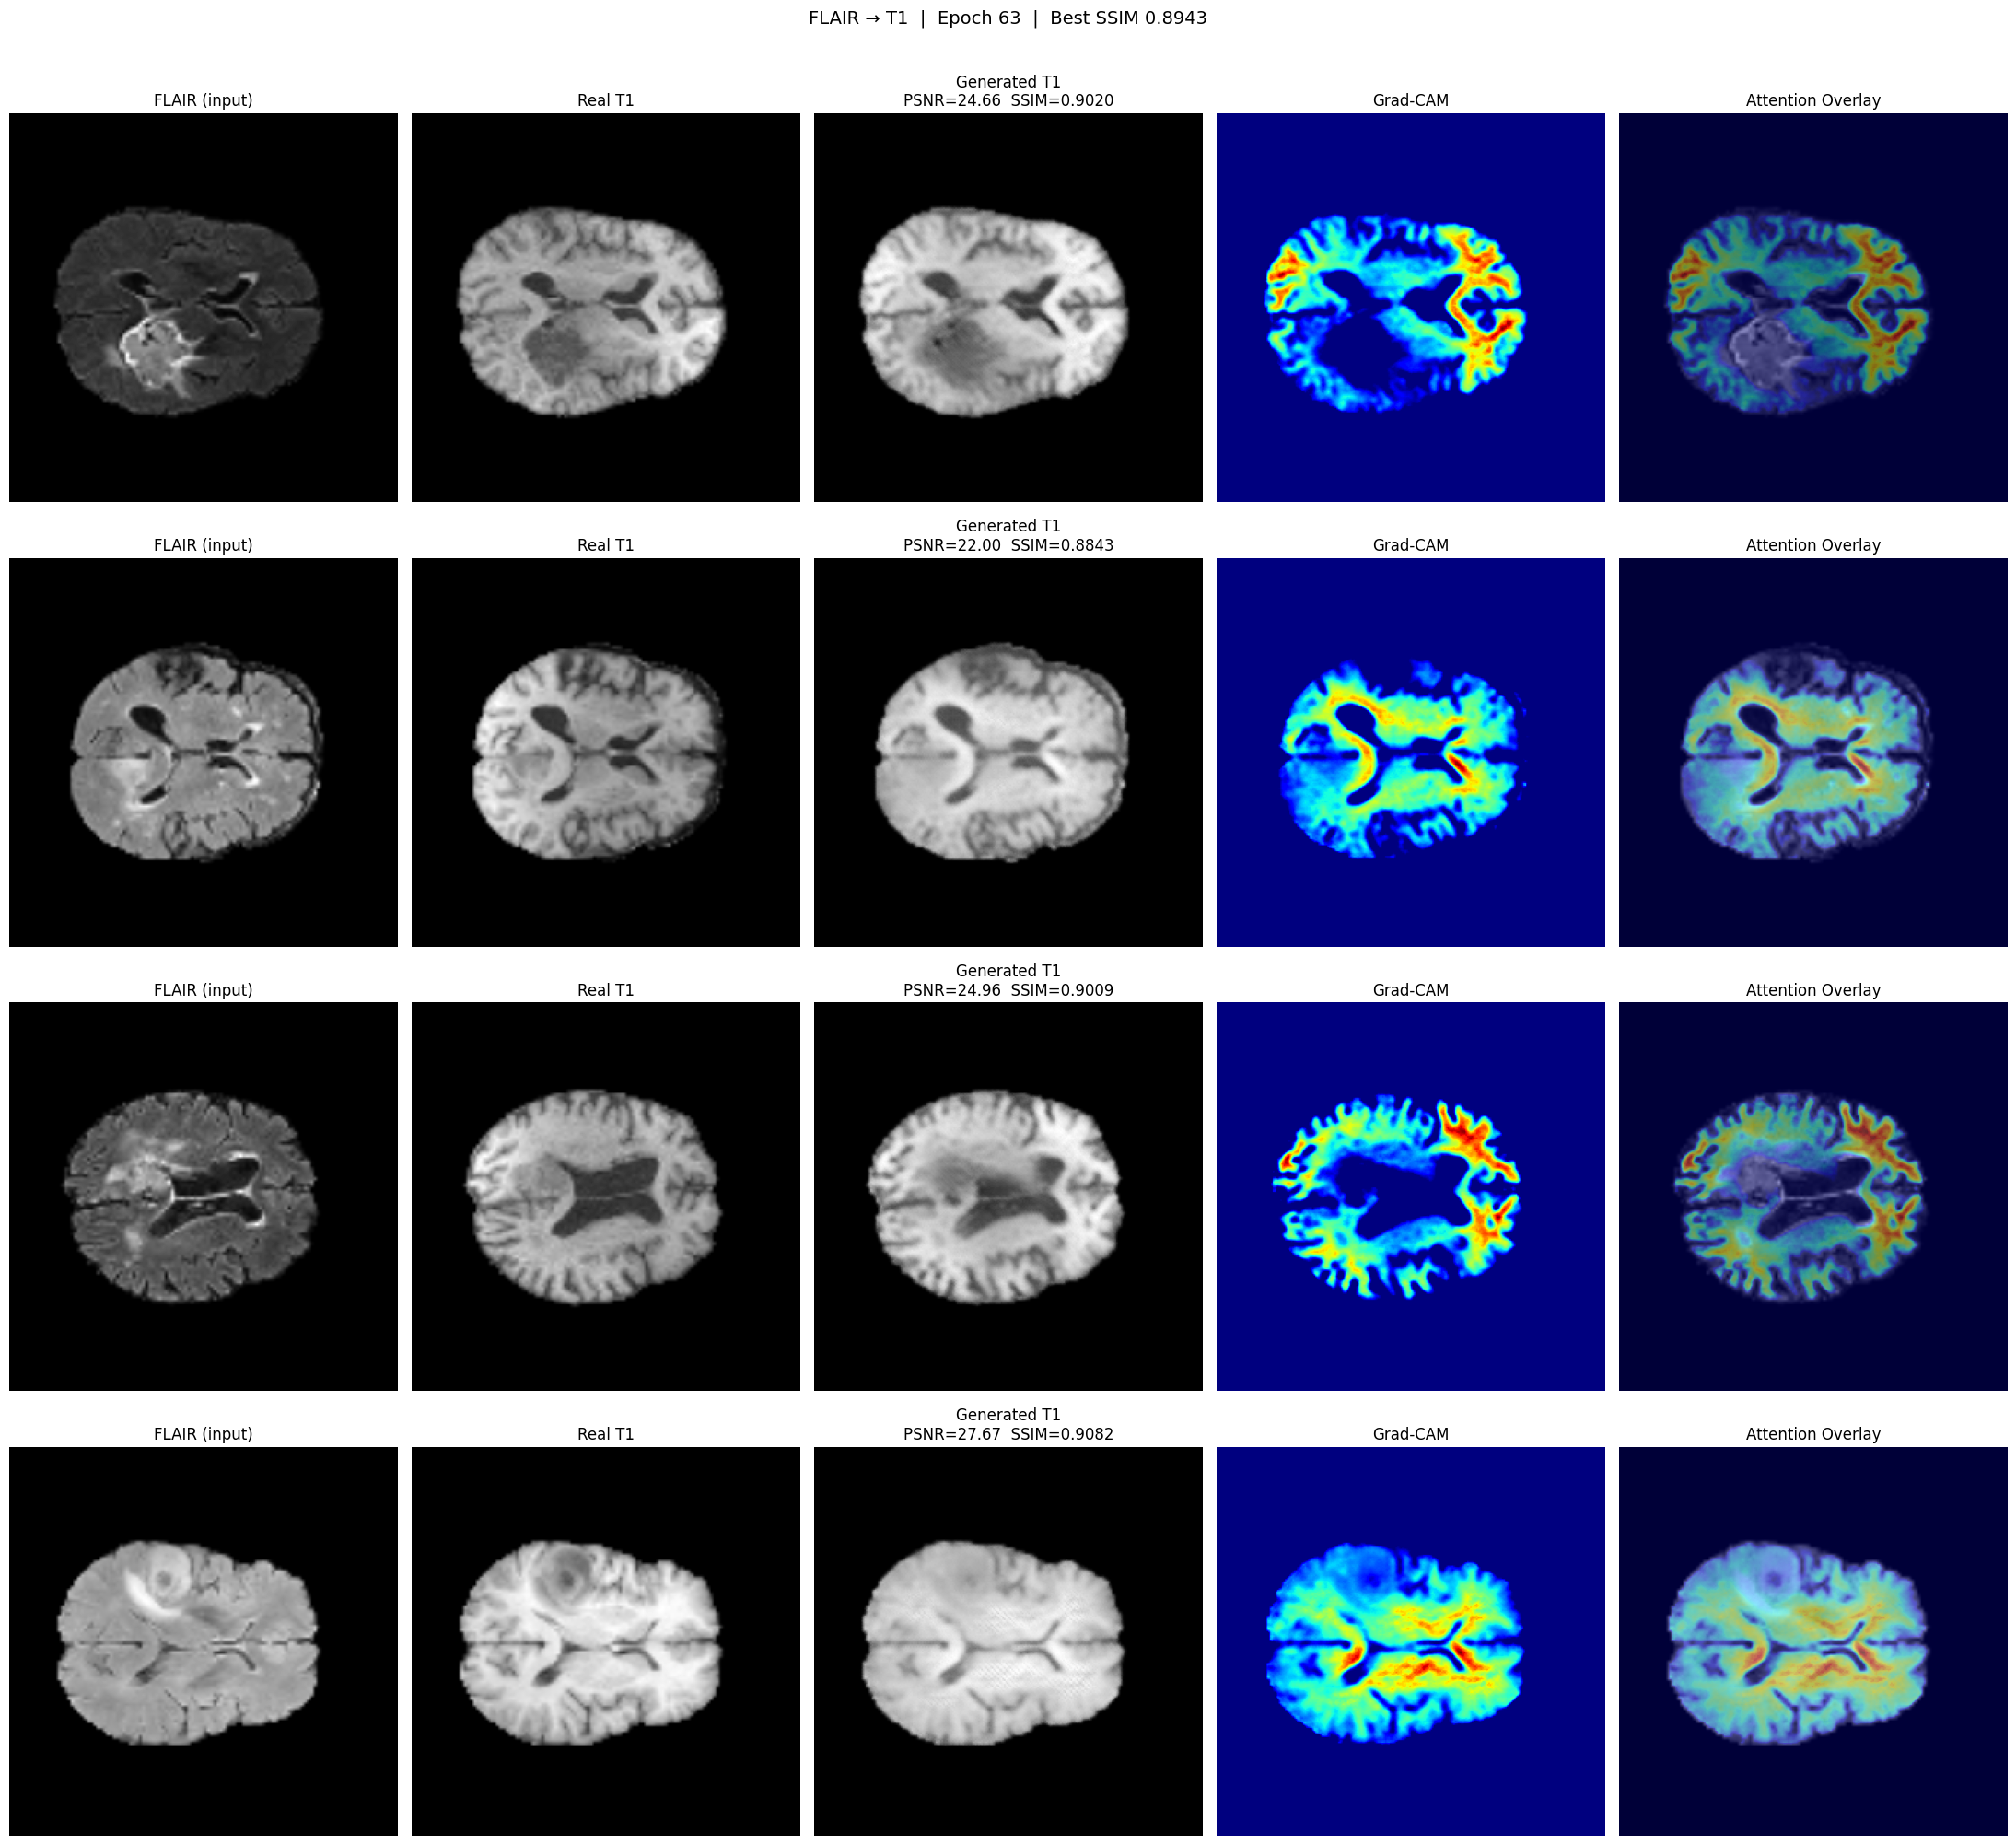

Saved → /home/atchu2504/training/outputs/resnet9_v6/resnet9/samples


: 

In [ ]:
import sys, os
sys.path.insert(0, '/home/atchu2504/training')

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from skimage.metrics import structural_similarity as ssim_fn
from skimage.metrics import peak_signal_noise_ratio as psnr_fn

from models import ResNet9Generator
from dataset import create_dataloaders

# ── config ───────────────────────────────────────────────────────────────────
CHECKPOINT = '/home/atchu2504/training/outputs/resnet9_v6/resnet9/checkpoints/best_model.pth'
DATA_DIR   = '/home/atchu2504/training/data'
CACHE_DIR  = '/home/atchu2504/training/cache'
device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── GradCAM ──────────────────────────────────────────────────────────────────
class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.activations = None
        self.gradients   = None
        target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, 'activations', o.detach()))
        target_layer.register_full_backward_hook(
            lambda m, gi, go: setattr(self, 'gradients', go[0].detach()))

    def __call__(self, x):
        self.model.zero_grad()
        out = self.model(x)
        out.mean().backward(retain_graph=True)
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam     = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam     = F.interpolate(cam, size=x.shape[2:], mode='bilinear', align_corners=False)
        for i in range(cam.size(0)):
            m = cam[i].max()
            if m > 0:
                cam[i] /= m
        return cam, out

# ── load model ────────────────────────────────────────────────────────────────
gen  = ResNet9Generator(in_channels=3, out_channels=3).to(device)
ckpt = torch.load(CHECKPOINT, map_location=device, weights_only=False)

# torch.compile saves weights with '_orig_mod.' prefix — strip it
state_dict = ckpt['gen']
if any(k.startswith('_orig_mod.') for k in state_dict.keys()):
    state_dict = {k.replace('_orig_mod.', ''): v for k, v in state_dict.items()}

gen.load_state_dict(state_dict)
gen.eval()
print(f"Loaded — epoch {ckpt['epoch']},  best SSIM {ckpt['best_ssim']:.4f}")

# target = last Conv2d in ResNet9Generator (output 7x7 conv, index 26)
target_layer = gen.model[26]
grad_cam = GradCAM(gen, target_layer)

# ── load validation batch ─────────────────────────────────────────────────────
_, val_loader, _, _ = create_dataloaders(
    DATA_DIR, batch_size=4, seed=42, num_workers=0, cache_dir=CACHE_DIR)
batch   = next(iter(val_loader))
flair   = batch['image'].to(device)
t1_real = batch['label'].to(device)
flair.requires_grad_(True)

# ── run GradCAM ───────────────────────────────────────────────────────────────
cam, t1_fake = grad_cam(flair)

def to01(t):
    return ((t.detach() + 1) / 2).clamp(0, 1)

flair_01 = to01(flair)
fake_01  = to01(t1_fake)
real_01  = to01(t1_real)

# ── visualise ─────────────────────────────────────────────────────────────────
n = min(4, flair.size(0))
fig, axes = plt.subplots(n, 5, figsize=(22, 5 * n))

for idx in range(n):
    f = flair_01[idx, 0].detach().cpu().numpy()
    r = real_01 [idx, 0].detach().cpu().numpy()
    g = fake_01 [idx, 0].detach().cpu().numpy()
    h = cam     [idx, 0].detach().cpu().numpy()

    psnr = psnr_fn(r, g, data_range=1.0)
    sval = ssim_fn(r, g, data_range=1.0)

    axes[idx, 0].imshow(f, cmap='gray');  axes[idx, 0].set_title('FLAIR (input)')
    axes[idx, 1].imshow(r, cmap='gray');  axes[idx, 1].set_title('Real T1')
    axes[idx, 2].imshow(g, cmap='gray');  axes[idx, 2].set_title(f'Generated T1\nPSNR={psnr:.2f}  SSIM={sval:.4f}')
    axes[idx, 3].imshow(h, cmap='jet');   axes[idx, 3].set_title('Grad-CAM')
    axes[idx, 4].imshow(f, cmap='gray')
    axes[idx, 4].imshow(h, cmap='jet', alpha=0.45)
    axes[idx, 4].set_title('Attention Overlay')

    for ax in axes[idx]:
        ax.axis('off')

plt.suptitle(
    f"FLAIR → T1  |  Epoch {ckpt['epoch']}  |  Best SSIM {ckpt['best_ssim']:.4f}",
    fontsize=14, y=1.01)
plt.tight_layout()

out_path = '/home/atchu2504/training/outputs/resnet9_v6/resnet9/samples'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {out_path}")


In [ ]:
"""
Dataset Overview — Subject Counts, File Sizes, Available Modalities
"""
import os
import numpy as np
import nibabel as nib
from pathlib import Path
from collections import Counter

# ── BraTS 2021 (Training) ──
brats21_dir = '/home/atchu2504/training/data'
brats21_subjects = sorted([d for d in os.listdir(brats21_dir)
                           if os.path.isdir(os.path.join(brats21_dir, d))])

# Count modalities per subject
brats21_modalities = Counter()
brats21_sizes_mb = []
for subj in brats21_subjects:
    subj_dir = os.path.join(brats21_dir, subj)
    files = os.listdir(subj_dir)
    for f in files:
        mod = f.replace(subj + '_', '').replace('.nii.gz', '')
        brats21_modalities[mod] += 1
        brats21_sizes_mb.append(os.path.getsize(os.path.join(subj_dir, f)) / 1e6)

# ── BraTS 2023 (External Validation) ──
brats23_root = '/home/atchu2504/training/validation/ASNR-MICCAI-BraTS2023-GLI-Challenge-ValidationData'
brats23_subjects = sorted([d for d in os.listdir(brats23_root)
                           if os.path.isdir(os.path.join(brats23_root, d))])

brats23_modalities = Counter()
brats23_sizes_mb = []
for subj in brats23_subjects:
    subj_dir = os.path.join(brats23_root, subj)
    files = os.listdir(subj_dir)
    for f in files:
        mod = f.replace(subj + '-', '').replace('.nii.gz', '')
        brats23_modalities[mod] += 1
        brats23_sizes_mb.append(os.path.getsize(os.path.join(subj_dir, f)) / 1e6)

print("=" * 65)
print("  DATASET OVERVIEW")
print("=" * 65)
print(f"\n{'BraTS 2021 (Training)':}")
print(f"  Subjects:     {len(brats21_subjects)}")
print(f"  Modalities:   {dict(brats21_modalities)}")
print(f"  Total files:  {sum(brats21_modalities.values())}")
print(f"  Total size:   {sum(brats21_sizes_mb)/1e3:.2f} GB")
print(f"  Avg file:     {np.mean(brats21_sizes_mb):.2f} MB")
print(f"  FLAIR files:  {brats21_modalities.get('flair', 0)}")
print(f"  T1 files:     {brats21_modalities.get('t1', 0)}")
print(f"  Paired:       {min(brats21_modalities.get('flair', 0), brats21_modalities.get('t1', 0))} FLAIR-T1 pairs")

print(f"\n{'BraTS 2023 GLI (External Validation)':}")
print(f"  Subjects:     {len(brats23_subjects)}")
print(f"  Modalities:   {dict(brats23_modalities)}")
print(f"  Total files:  {sum(brats23_modalities.values())}")
print(f"  Total size:   {sum(brats23_sizes_mb)/1e3:.2f} GB")
print(f"  FLAIR (t2f):  {brats23_modalities.get('t2f', 0)}")
print(f"  T1 (t1n):     {brats23_modalities.get('t1n', 0)}")
print(f"  Paired:       {min(brats23_modalities.get('t2f', 0), brats23_modalities.get('t1n', 0))} FLAIR-T1 pairs")

print(f"\n{'Train/Val Split (80/20)':}")
n_train = int(len(brats21_subjects) * 0.8)
n_val = len(brats21_subjects) - n_train
print(f"  Training:     {n_train} subjects")
print(f"  Validation:   {n_val} subjects")
print("=" * 65)

"""
Cell 2/4: Volume-Level Statistics — Spatial Dimensions, Voxel Spacing, Intensity Stats
Samples 50 subjects from each dataset for efficiency.
"""
import nibabel as nib
import numpy as np
import os

def analyze_volumes(data_dir, subjects, flair_fmt, t1_fmt, n_sample=50):
    """Compute volume-level stats for a list of subjects."""
    rng = np.random.RandomState(42)
    sample = rng.choice(subjects, min(n_sample, len(subjects)), replace=False)

    stats = {'flair_shape': [], 't1_shape': [], 'flair_spacing': [], 't1_spacing': [],
             'flair_min': [], 'flair_max': [], 'flair_mean': [], 'flair_std': [],
             't1_min': [], 't1_max': [], 't1_mean': [], 't1_std': [],
             'flair_nonzero_pct': [], 't1_nonzero_pct': []}

    for subj in sample:
        flair_path = os.path.join(data_dir, subj, flair_fmt(subj))
        t1_path = os.path.join(data_dir, subj, t1_fmt(subj))
        if not (os.path.exists(flair_path) and os.path.exists(t1_path)):
            continue

        f_nii = nib.load(flair_path)
        t_nii = nib.load(t1_path)
        f_data = f_nii.get_fdata()
        t_data = t_nii.get_fdata()

        stats['flair_shape'].append(f_data.shape)
        stats['t1_shape'].append(t_data.shape)
        stats['flair_spacing'].append(tuple(np.round(f_nii.header.get_zooms()[:3], 3)))
        stats['t1_spacing'].append(tuple(np.round(t_nii.header.get_zooms()[:3], 3)))

        stats['flair_min'].append(f_data.min())
        stats['flair_max'].append(f_data.max())
        stats['flair_mean'].append(f_data[f_data > 0].mean() if (f_data > 0).any() else 0)
        stats['flair_std'].append(f_data[f_data > 0].std() if (f_data > 0).any() else 0)
        stats['flair_nonzero_pct'].append((f_data > 0).sum() / f_data.size * 100)

        stats['t1_min'].append(t_data.min())
        stats['t1_max'].append(t_data.max())
        stats['t1_mean'].append(t_data[t_data > 0].mean() if (t_data > 0).any() else 0)
        stats['t1_std'].append(t_data[t_data > 0].std() if (t_data > 0).any() else 0)
        stats['t1_nonzero_pct'].append((t_data > 0).sum() / t_data.size * 100)

    return stats

# BraTS 2021
brats21_dir = '/home/atchu2504/training/data'
brats21_subjects = sorted([d for d in os.listdir(brats21_dir) if os.path.isdir(os.path.join(brats21_dir, d))])
stats21 = analyze_volumes(
    brats21_dir, brats21_subjects,
    flair_fmt=lambda s: f"{s}_flair.nii.gz",
    t1_fmt=lambda s: f"{s}_t1.nii.gz",
    n_sample=50
)

# BraTS 2023
brats23_root = '/home/atchu2504/training/validation/ASNR-MICCAI-BraTS2023-GLI-Challenge-ValidationData'
brats23_subjects = sorted([d for d in os.listdir(brats23_root) if os.path.isdir(os.path.join(brats23_root, d))])
stats23 = analyze_volumes(
    brats23_root, brats23_subjects,
    flair_fmt=lambda s: f"{s}-t2f.nii.gz",
    t1_fmt=lambda s: f"{s}-t1n.nii.gz",
    n_sample=50
)

def print_stats(name, stats):
    print(f"\n{'='*65}")
    print(f"  {name} — Volume Statistics (n={len(stats['flair_shape'])} sampled)")
    print(f"{'='*65}")

    shapes = set(stats['flair_shape'])
    print(f"\n  Spatial dimensions:  {shapes if len(shapes) <= 3 else f'{list(shapes)[:3]}... ({len(shapes)} unique)'}")
    spacings = set(stats['flair_spacing'])
    print(f"  Voxel spacing (mm): {spacings if len(spacings) <= 3 else f'{list(spacings)[:3]}... ({len(spacings)} unique)'}")

    for mod in ['flair', 't1']:
        label = 'FLAIR' if mod == 'flair' else 'T1'
        print(f"\n  {label} Intensity (non-zero voxels):")
        print(f"    Mean:      {np.mean(stats[f'{mod}_mean']):.2f} +/- {np.std(stats[f'{mod}_mean']):.2f}")
        print(f"    Std:       {np.mean(stats[f'{mod}_std']):.2f} +/- {np.std(stats[f'{mod}_std']):.2f}")
        print(f"    Min:       {np.mean(stats[f'{mod}_min']):.2f}")
        print(f"    Max:       {np.mean(stats[f'{mod}_max']):.2f} +/- {np.std(stats[f'{mod}_max']):.2f}")
        print(f"    Non-zero:  {np.mean(stats[f'{mod}_nonzero_pct']):.1f}% +/- {np.std(stats[f'{mod}_nonzero_pct']):.1f}%")

print_stats("BraTS 2021 (Training)", stats21)
print_stats("BraTS 2023 GLI (External Validation)",stats23)

  DATASET OVERVIEW

BraTS 2021 (Training)
  Subjects:     1251
  Modalities:   {'seg': 1251, 't1ce': 1251, 't1': 1251, 'flair': 1251, 't2': 1251}
  Total files:  6255
  Total size:   13.38 GB
  Avg file:     2.14 MB
  FLAIR files:  1251
  T1 files:     1251
  Paired:       1251 FLAIR-T1 pairs

BraTS 2023 GLI (External Validation)
  Subjects:     219
  Modalities:   {'t1c': 219, 't2w': 219, 't1n': 219, 't2f': 219}
  Total files:  876
  Total size:   2.39 GB
  FLAIR (t2f):  219
  T1 (t1n):     219
  Paired:       219 FLAIR-T1 pairs

Train/Val Split (80/20)
  Training:     1000 subjects
  Validation:   251 subjects

  BraTS 2021 (Training) — Volume Statistics (n=50 sampled)

  Spatial dimensions:  {(240, 240, 155)}
  Voxel spacing (mm): {(1.0, 1.0, 1.0)}

  FLAIR Intensity (non-zero voxels):
    Mean:      434.98 +/- 349.88
    Std:       149.25 +/- 130.09
    Min:       0.00
    Max:       1368.93 +/- 974.60
    Non-zero:  16.6% +/- 2.0%

  T1 Intensity (non-zero voxels):
    Mean:      